### Import Packages

In [1]:
import matplotlib.pyplot as plt
import csv
import numpy as np
import random
from scipy.fft import fft, fftfreq

### Analysis and Plotting

In [3]:
def decompose(
    data,
):  # decompose data from string (with space delimited) to a float array
    return np.fromstring(data, dtype=float, sep=" ")


def get_fft(x, T, N):  # fft converting
    f = fftfreq(N, T)[: N // 2]
    y_mag = 2 / N * np.abs(fft(x)[: N // 2])
    y_mag[0] = 0
    return f, y_mag


class ADXLOutput:
    def __init__(self, filename: str, R=random.randint(0, 9)):
        """ADXLOutput is a class for reading ADXL data from a CSV file and generating time and frequency domain plots.
        Args:
            filename (str): The path to the CSV file containing the ADXL data.
            R (int, optional): A specific row of data for plotting. Defaults to a random integer between 0 and 9.
        """
        self.filename = filename
        self.data = []
        self.N = 1000
        self.T = 1 / self.N
        self.R = R
        self.t = np.linspace(0, 1, self.N)

        # Reading a CSV file and convert rows as data
        with open(self.filename, "r") as f:
            self.rows = csv.reader(f, delimiter=",")
            header = next(self.rows)
            for row in self.rows:
                self.data.append(row)

        self.data = np.array(self.data)  # converting data as numpy array

    def adjust_data(self, upper_bound, lower_bound):
        self.data = self.data[
            (self.data[:, 1].astype(float) < upper_bound)
            & (self.data[:, 1].astype(float) > lower_bound)
        ]

    def generate_plot(self):
        condition = self.data[self.R][0]  # get the condition string
        your_name = "Robert Claud"  # input your name
        Time_title = "Time domain, " + condition + ", " + your_name
        Freq_title = "Freq domain, " + condition + ", " + your_name

        a_x = decompose(self.data[self.R][1])  # X-axis acceleration array
        a_y = decompose(self.data[self.R][2])  # Y-axis acceleration array
        a_z = decompose(self.data[self.R][3])  # Z-axis acceleration array

        fig, ax = plt.subplots(
            3, 2, squeeze=False
        )  # plotting time domain for 3-axis

        fig.suptitle(Time_title)
        ax[0, 0].plot(self.t, a_x, "tab:blue")
        ax[0, 0].set_ylabel("a_x [m/s2]")
        ax[1, 0].plot(self.t, a_y, "tab:orange")
        ax[1, 0].set_ylabel("a_y [m/s2]")
        ax[2, 0].plot(self.t, a_z, "tab:green")
        ax[2, 0].set_ylabel("a_z [m/s2]")
        ax[2, 0].set_xlabel("Time [sec]")

        f_x, y_x = get_fft(a_x, self.T, self.N)
        f_y, y_y = get_fft(a_y, self.T, self.N)
        f_z, y_z = get_fft(a_z, self.T, self.N)

        fig.suptitle(Freq_title)
        ax[0, 1].plot(f_x, y_x, "tab:blue")
        ax[0, 1].set_ylabel("|FFT| of a_x")
        ax[1, 1].plot(f_y, y_y, "tab:orange")
        ax[1, 1].set_ylabel("|FFT| of a_y")
        ax[2, 1].plot(f_z, y_z, "tab:green")
        ax[2, 1].set_ylabel("|FFT| of a_z")
        ax[2, 1].set_xlabel("Frequency [Hz]")

        plt.tight_layout()
        plt.show()

### Test with Files

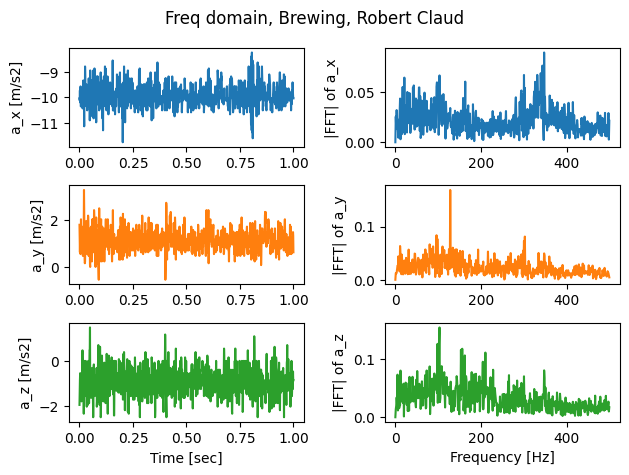

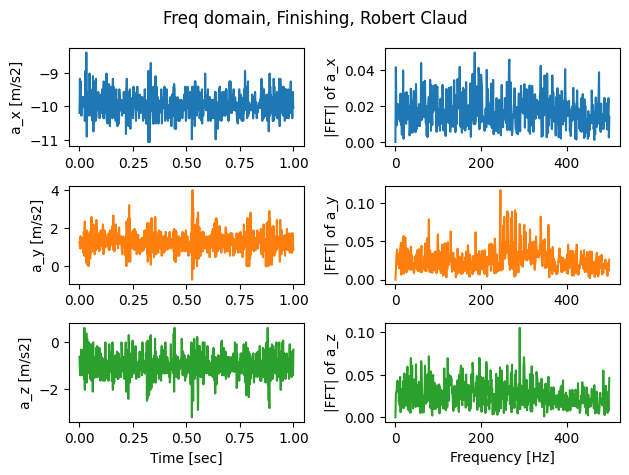

In [12]:
brewing_output = ADXLOutput(
    r"./data/20260421_224126_Brewing_lab8_data.csv", R=random.randint(0, 300)
)
brewing_output.generate_plot()

finishing_output = ADXLOutput(
    r"./data/20260421_224826_Finishing_lab8_data.csv", R=random.randint(0, 34)
)
finishing_output.generate_plot()